<a href="https://colab.research.google.com/github/umiSirya/kenya_public_debt/blob/main/kenya_debt_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Kenya Public Debt Analysis — Project Summary

**Dataset Source:** Open Africa — Kenya Public Debt
([open.africa/dataset/kenya-public-debt](https://open.africa/dataset/kenya-public-debt))

**Dataset Overview:**
The dataset contains **262 records** of Kenya's public debt spanning **22 years from 1999 to 2021**, recorded on a monthly basis. It consists of 5 columns — Year, Month, Domestic Debt, External Debt and Total Debt — all measured in Kenya Shillings (KES) millions.

---

**Key Findings:**

1. **Kenya's public debt has grown exponentially** over the 22-year period, rising from approximately KES 500,000M in 1999 to over KES 8,200,000M by December 2021  a growth of over **1,500%.**

2. **Domestic vs External Debt** both grew consistently, with External Debt becoming an increasingly significant contributor to Total Debt in later years.

3. **The debt growth accelerated sharply after 2015**, visible in the hockey-stick curve observed during Exploratory Data Analysis (EDA).

4. **A Polynomial Regression model (degree=3)** was the most suitable model for predicting Total Debt using time based features, achieving an **R² score of 0.9069** and a **Mean Absolute Error (MAE) of KES 283,394M**  meaning the model explains approximately 91% of Kenya's debt growth pattern.

---

**Other Factors That Affect Public Debt (Not in Dataset):**


| Factor | How it affects Debt |
|---|---|
| **GDP Growth** | Higher GDP = more tax revenue = less need to borrow |
| **Inflation Rate** | High inflation increases cost of repaying foreign loans |
| **Exchange Rate (KES/USD)** | A weaker shilling makes external debt more expensive to repay |
| **Government Spending** | Infrastructure projects (SGR, roads) drove major borrowing after 2013 |
| **Interest Rates** | Higher rates = more expensive to borrow = debt grows faster |
| **IMF/World Bank Loans** | Large institutional loans cause sudden debt spikes |
| **COVID-19 (2020-2021)** | Pandemic spending caused a sharp borrowing increase worldwide |
| **Political decisions** | Budget deficits, tax policy and election cycles influence borrowing |
| **Oil prices** | Kenya imports oil — high prices increase government expenditure |
| **Population growth** | More people = more demand for public services = more spending |



**Conclusion:**

Kenya's public debt has followed a consistent and steep upward trajectory over the past two decades, driven by a combination of infrastructure investment, foreign borrowing, currency depreciation and pandemic related spending. While our model successfully captured the time-based growth trend, a more comprehensive predictive model would incorporate macroeconomic indicators such as GDP, inflation and exchange rates alongside the time features used here.


In [136]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score




In [137]:
# Importing the dataset
df = pd.read_csv('public-debt-ksh-million.csv')
df

,Year,Month,Domestic Debt,External Debt,Total
0,2021,December,"4,032,368.18","4,174,371.53","8,206,739.71"
1,2021,November,"4,008,077.30","4,109,282.85","8,117,360.15"
2,2021,October,"3,959,523.30","4,083,124.54","8,042,647.84"
3,2021,September,"3,937,777.45","4,062,504.78","8,000,282.23"
4,2021,August,"3,864,875.78","4,054,862.85","7,919,738.63"
...,...,...,...,...,...
257,2000,July,"202,362.00","394,667.37","597,029.37"
258,2000,June,"206,127.00","395,694.00","601,821.00"
259,2000,March,"201,463.22","396,800.00","598,263.22"
260,1999,December,"190,300.00","311,953.00","502,253.00"


# **Data Exploration**

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           262 non-null    int64 
 1   Month          262 non-null    object
 2   Domestic Debt  262 non-null    object
 3   External Debt  262 non-null    object
 4   Total          262 non-null    object
dtypes: int64(1), object(4)
memory usage: 10.4+ KB


In [139]:
df.describe()

,Year
count,262.000000
mean,2010.572519
std,6.327015
min,1999.000000
25%,2005.000000
50%,2011.000000
75%,2016.000000
max,2021.000000


In [140]:
#converting dtype object to number and remove commas and convert to numbers
df["Domestic Debt"] = df["Domestic Debt"].str.replace(",", "").astype(float)
df["External Debt"] = df["External Debt"].str.replace(",", "").astype(float)
df["Total"]         = df["Total"].str.replace(",", "").astype(float)

In [141]:
df.head()

,Year,Month,Domestic Debt,External Debt,Total
0,2021,December,4032368.18,4174371.53,8206739.71
1,2021,November,4008077.30,4109282.85,8117360.15
2,2021,October,3959523.30,4083124.54,8042647.84
3,2021,September,3937777.45,4062504.78,8000282.23
4,2021,August,3864875.78,4054862.85,7919738.63


In [142]:
#confirming that the dtype has been changed from object to float64
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           262 non-null    int64  
 1   Month          262 non-null    object 
 2   Domestic Debt  262 non-null    float64
 3   External Debt  262 non-null    float64
 4   Total          262 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 10.4+ KB


In [143]:
#checking for null values
df.isnull().sum()



,0
Year,0
Month,0
Domestic Debt,0
External Debt,0
Total,0


In [144]:
# saving clean dataset to csv
df.to_csv("clean_public_debt.csv", index=False)

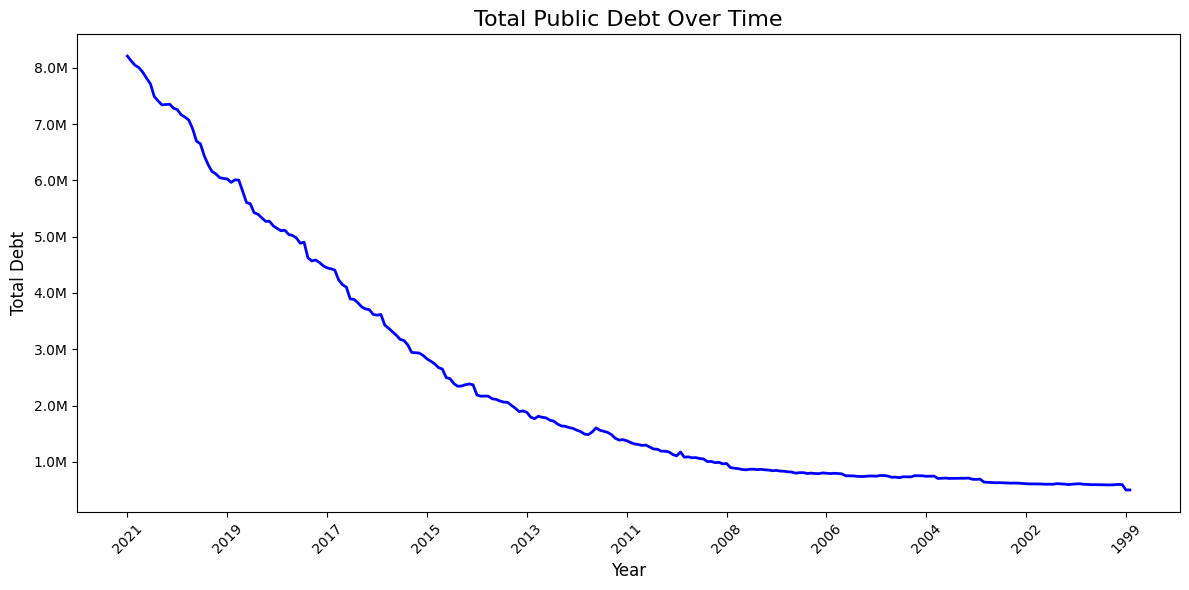

In [145]:
# Visualization of the debt over time
plt.figure(figsize=(12, 6))
plt.plot(df["Total"].values, color="blue", linewidth=2)

#  Plot the FULL actual debt over time to see the real shape
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))

total_rows = len(df)
step = total_rows // 10               # Show ~10 year labels
tick_positions = range(0, total_rows, step)
tick_labels = df["Year"].iloc[::step].values

plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45)

plt.title("Total Public Debt Over Time", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Debt", fontsize=12)
plt.tight_layout()
plt.show()


# **Data Pre-processing**

In [146]:
# Encode month + sort chronologically
df["Month_Num"]   = pd.to_datetime(df["Month"], format="%B").dt.month
df                = df.sort_values(["Year", "Month_Num"], ascending=True).reset_index(drop=True)
df["Time_Index"]  = range(len(df))

# Features and target
X = df[["Time_Index"]]
y = df["Total"]




# **Train and Test Split**

In [147]:
# Chronological split
split   = int(len(df) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Training years: {df['Year'].iloc[0]} → {df['Year'].iloc[split-1]}")
print(f"Testing years:  {df['Year'].iloc[split]} → {df['Year'].iloc[-1]}")


Training years: 1999 → 2017
Testing years:  2017 → 2021


In [148]:
# Polynomial transformation (degree=3)
poly         = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)  # Learn AND transform training data
X_test_poly  = poly.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [149]:
# Model Evaluation

y_pred = model.predict(X_test_poly)
mae    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)

print(f"\nMAE:      {mae:,.2f}")
print(f"R² Score: {r2:.4f}")


MAE:      283,393.62
R² Score: 0.9069


In [150]:
# Fit Linear Regression on the curved features

model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE:      {mae:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE:      283,393.62
R² Score: 0.9069


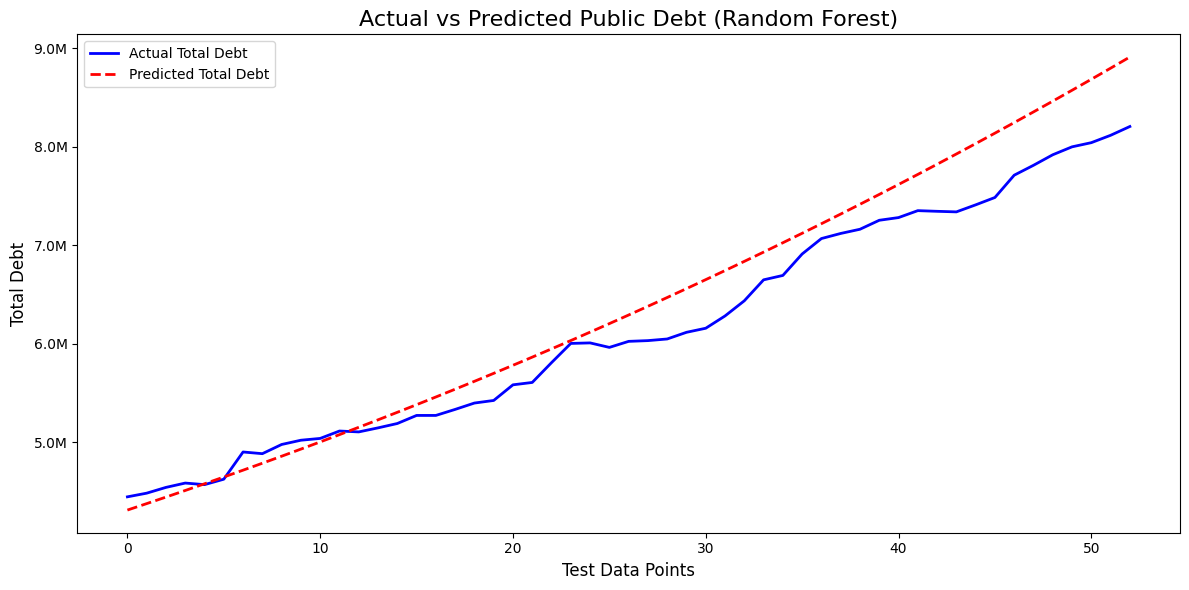

In [151]:
# Actual vs Predicted Debt

# Plot with proper formatting
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Total Debt",    color="blue", linewidth=2)
plt.plot(y_pred,        label="Predicted Total Debt", color="red",  linestyle="--", linewidth=2)

# Format Y axis as Millions
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))

plt.title("Actual vs Predicted Public Debt (Random Forest)", fontsize=16)
plt.xlabel("Test Data Points", fontsize=12)
plt.ylabel("Total Debt", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()